In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

In [3]:
import joblib

rf_model = joblib.load("final_random_forest_model.pkl")

X_test = joblib.load("X_test.pkl")
y_test = joblib.load("y_test.pkl")

print("Files loaded successfully!")
print(X_test.shape)

Files loaded successfully!
(20354, 193)


In [5]:
y_prob = rf_model.predict_proba(X_test)[:, 1]

print(y_prob[:10])

[0.52864255 0.45692774 0.48778921 0.52527739 0.49833007 0.43663516
 0.38884681 0.40785802 0.57703518 0.6000516 ]


In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("AUC =", auc)

AUC = 0.6638575882289243


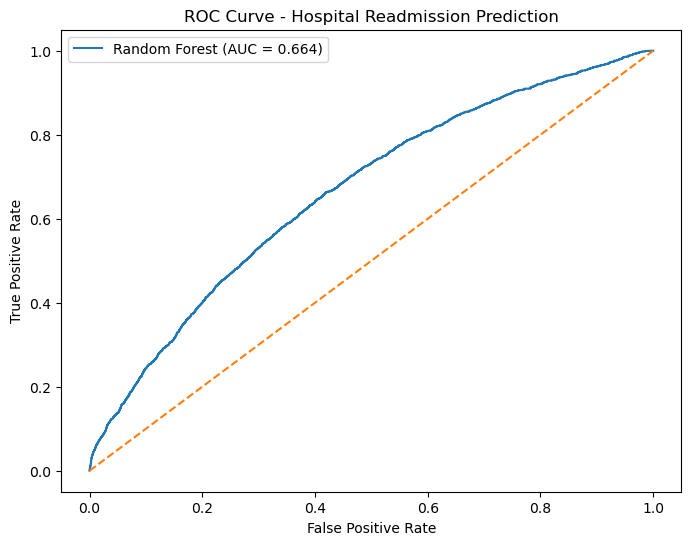

In [9]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hospital Readmission Prediction")
plt.legend()

plt.show()

In [13]:
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head()

,Feature,Importance
9,number_inpatient,0.237850
1,discharge_disposition_id,0.094663
8,number_emergency,0.052396
6,num_medications,0.049371
3,time_in_hospital,0.047895


In [15]:
import matplotlib.pyplot as plt

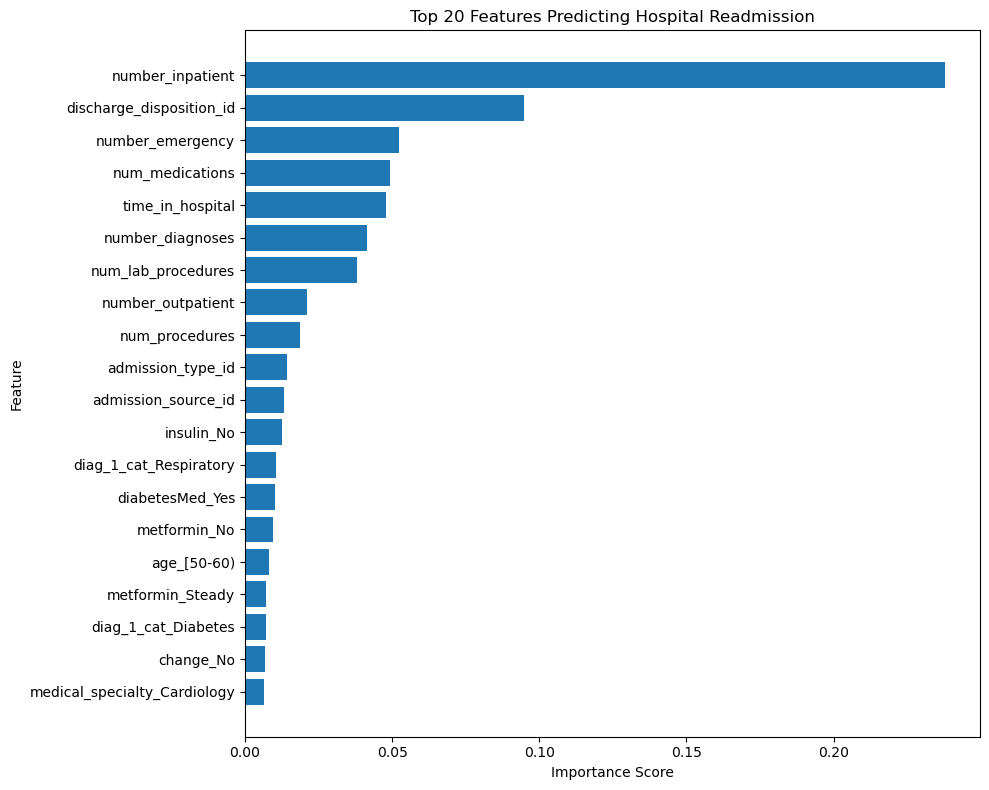

In [17]:
top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20['Feature'][::-1],
    top20['Importance'][::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 20 Features Predicting Hospital Readmission")

plt.tight_layout()
plt.show()